## Assignment 6: Simulating the Ising Model

In this project, you will build a simple simulation of how spins behave on a grid at different temperatures. Think of it as a game where:

You have a checkerboard with squares. Each square contains a tiny arrow pointing either up or down. When temperature is low, nearby arrows want to point the same way (to save energy). When temperature is high, arrows flip randomly and ignore their neighbors. Your task is to simulate this, watch patterns emerge, and create pictures showing what happens. Even if you do not understand the physics deeply, just follow the algorithm step by step.

### WHAT YOU WILL BUILD
#### Part 1: The Code Structure
Your notebook should have these clear sections:
1. Import libraries (numpy, matplotlib)
2. Create a grid of random spins (size 50x50 is good)
3. Write a function to calculate energy difference when one spin flips
4. Write the Metropolis algorithm (decide if flip is accepted)
5. Run simulation at multiple temperatures and save final patterns
6. Create visualizations

#### Part 2: Run at Different Temperatures
Run your simulation at exactly these 5 temperatures:
- Temperature = 0.5 (very cold, spins organize nicely)
- Temperature = 1.0 (cold, some flipping)
- Temperature = 2.0 (medium)
- Temperature = 2.5 (warm, more random)
- Temperature = 4.0 (hot, complete chaos)

For each temperature, run at least 5000 steps so the pattern becomes clear.

#### Part 3: Create 2 Visualizations
1. Grid Comparison: Show 5 images in a row. Each image is the final spin
grid at one temperature. Color: white for spin up, black for spin down. Label
each temperature. This shows how the pattern changes from ordered (cold)
to random (hot).
2. One Temperature Over Time: Pick cold temperature (0.5 or 1.0). Show
4 snapshots: after 500 steps, 1500 steps, 3000 steps, 5000 steps. Arrange in
a 2x2 grid. This shows how the pattern develops from random start to final
state.
3. Describe in a Markdown Cell: : What do you see at cold vs hot? Where
does the change happen?

#### WHAT RESULTS SHOULD LOOK LIKE
At cold temperature (T = 0.5 or 1.0): You see large white or black regions. The
spins form clusters and stay organized. It looks clean and structured.

At medium temperature (T = 2.0 or 2.5): You see mixed regions. Some organization but also randomness. Patches of white and black scattered around.

At hot temperature (T = 4.0): The grid looks like television static or noise.
White and black pixels scattered randomly everywhere. No obvious pattern.
This change from organized to random is the phase transition. It happens
somewhere between temperature 1.0 and 2.5.

In [63]:
# importing matplotlib for plotting and numpy for mathematical operations
import matplotlib.pyplot as plt
import numpy as np

In [64]:
def create_grid(m=50, n=50):
    # This function takes number of rows and columns and returns
    # an mxn matrix with all the elements either 1 or -1
    # Default is a 50x50 matrix
    grid = np.random.choice([-1, 1], size=(m, n))
    return grid

In [65]:

def get_spins(x, y, grid):
    # This function gives the sum of all the neighbouring spins of a particular point (x, y) in the grid
    rows, cols = grid.shape
    return (grid[x, (y+1) % cols] + grid[x, (y-1) % cols] + grid[(x+1) % rows, y] +grid[(x-1) % rows, y])

In [66]:
def metropolis(grid, T, steps=5000, J=1):
    M, N = grid.shape   # Number of rows and columns of the Grid
    chain = []          # This is the chain of all the 'steps' states

    for _ in range(steps):
        # We try to visit each point in our grid at least once
        for _ in range(M*N):

            # We chose a random point (x, y)
            x = np.random.randint(0, M)
            y = np.random.randint(0, N)

            # We find the current spin of that point. It's either +1 or -1
            current_spin = grid[x, y]

            # We calculate the change in energy if we flip the spin of that point
            dE = 2 * J * current_spin * get_spins(x, y, grid)

            # If the flip reduces energy, we will accept the flip
            if dE < 0:
                grid[x, y] *= -1

            # Otherwise, if the flip increases the energy
            # accept only if r (a uniform random value between 0 to 1) 
            # is less than exp(-dE / T), where T is temperature.
            else:
                if np.random.rand() < np.exp(-dE / T):
                    grid[x, y] *= -1
                else:
                    pass
        
        # Add the grid to the list of chain
        chain.append(grid.copy())

    # Making the chain into a np.array for convenience
    chain = np.array(chain)

    return chain


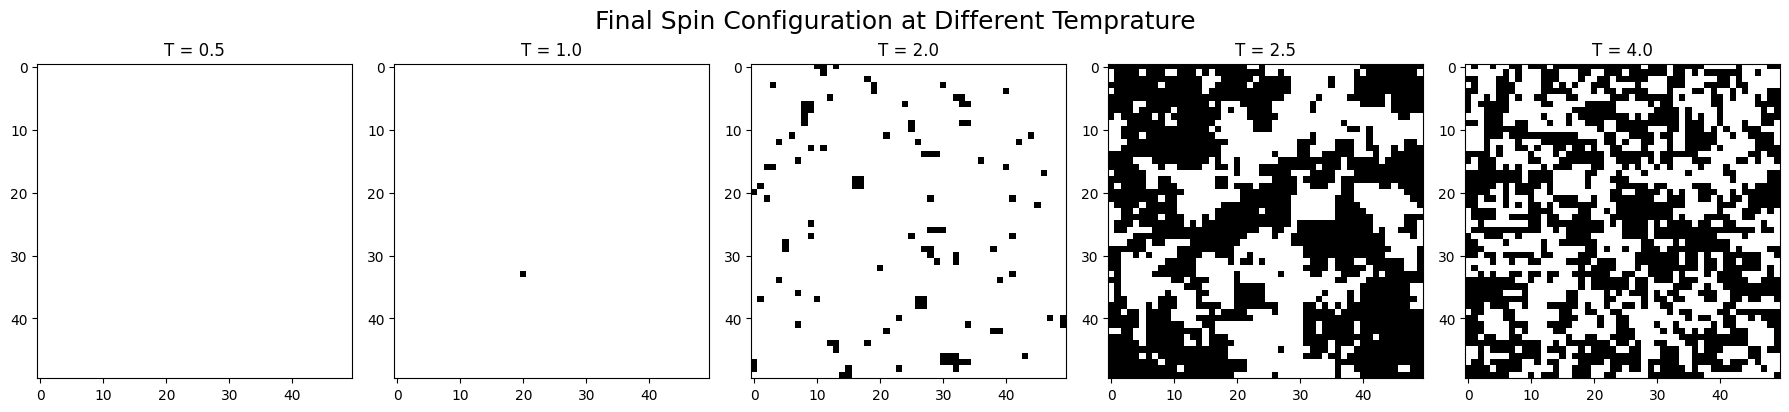

In [67]:
temps = [0.5, 1.0, 2.0, 2.5, 4.0]   # Tempratures for which we have to run the simulations
final_grid = []                     # We will store the final grid at these tempratures in this list

for T in temps:
    grid = create_grid()            # Creating a new grid for each T in temps
    chain = metropolis(grid, T)     # Getting its state-chain using metropolis()
    final_grid.append(chain[-1])    # Adding the final state into the final_grid list

plt.figure(figsize=(18, 4))         # Setting the size for out Figure

for i in range(len(temps)):
    # Plotting the graph for each Temprature
    plt.subplot(1, 5, i+1)          
    plt.imshow(final_grid[i], cmap="binary")
    plt.title(f"T = {temps[i]}")

# Adding the title and all the necessary things.
plt.suptitle("Final Spin Configuration at Different Temprature", fontsize=18)
plt.tight_layout()
plt.show()

At cold temperatures (T=0.5 and 1.0), the spins form large, organized regions. 

At medium temperatures (T=2.0 and 2.5), there's partial order with mixed patches and more randomness. The Critical Temprature is also somewhere around here.

At hot temperatures (T=4.0), the grid is completely chaotic, like static noise, with no patterns because flips are random. 

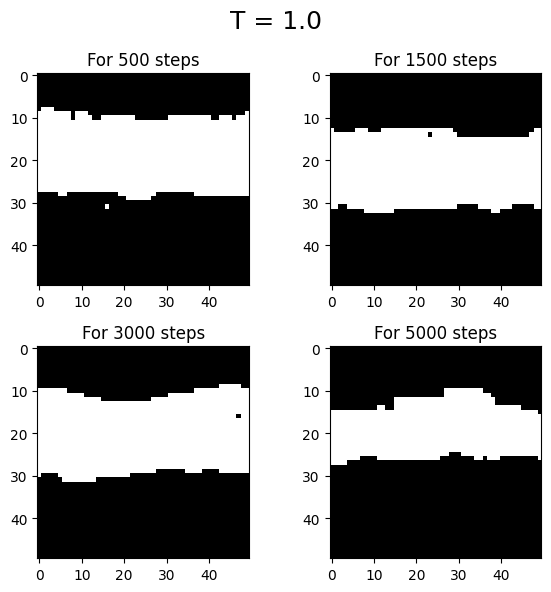

In [68]:
T = 1.0                         # Plotting 4 snapshots at T = 1.0 at 500, 1500, 3000, 5000 steps

grid = create_grid()            # Creating a new grid
chain = metropolis(grid, T)     # Getting the Chain

plt.figure(figsize=(6, 6))

# Visualizing the Plots on a 2x2 Figure
plt.subplot(2, 2, 1)
plt.imshow(chain[499], cmap="binary")
plt.title("For 500 steps")

plt.subplot(2, 2, 2)
plt.imshow(chain[1499], cmap="binary")
plt.title("For 1500 steps")

plt.subplot(2, 2, 3)
plt.imshow(chain[2999], cmap="binary")
plt.title("For 3000 steps")

plt.subplot(2, 2, 4)
plt.imshow(chain[4999], cmap="binary")
plt.title("For 5000 steps")

# Adding the title and all the necessary things.
plt.suptitle(f"T = {T}", fontsize=18)
plt.tight_layout()
plt.show()

For colder Temprature, the system attains an equilibrium state quite early on and remains in an somewhat "ordered" state.